In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Chargement des données préparées
df = pd.read_csv('C:/Users/dell/Desktop/projet-datamining/Dataminig-Project/data/processed/accidents_cleaned.csv')

print(df.shape)
df.head()


(197644, 34)


,Day_of_Week,Junction_Control,Junction_Detail,Latitude,Light_Conditions,Longitude,Number_of_Casualties,Number_of_Vehicles,Road_Surface_Conditions,Speed_limit,...,Weather_Conditions_Snowing + high winds,Weather_Conditions_Snowing no high winds,Road_Type_Dual carriageway,Road_Type_One way street,Road_Type_Roundabout,Road_Type_Single carriageway,Road_Type_Slip road,Urban_or_Rural_Area_Rural,Urban_or_Rural_Area_Urban,Accident_Severity_encoded
0,4,4,8,-0.720768,4,0.794163,0.0,0.309659,0,-0.602311,...,False,False,False,True,False,False,False,False,True,2
1,1,4,0,-0.718995,4,0.795690,0.0,0.309659,4,-0.602311,...,False,False,False,False,False,True,False,False,True,2
2,3,4,8,-0.742115,4,0.809963,0.0,0.309659,0,-0.602311,...,False,False,False,False,False,True,False,False,True,3
3,1,2,8,-0.724493,4,0.792884,0.0,0.309659,2,-0.602311,...,False,False,False,False,False,True,False,False,True,2
4,5,2,0,-0.745943,1,0.814434,0.0,0.309659,0,-0.602311,...,False,False,False,False,False,True,False,False,True,2


In [4]:
from sklearn.preprocessing import StandardScaler

# Variables numériques uniquement (sans la cible)
cols_pca = [
    'Speed_limit',
    'Number_of_Casualties',
    'Number_of_Vehicles',
    'Hour',
    'Is_Night',
    'Weekend',
    'Latitude',
    'Longitude'
]

X = df[cols_pca].dropna()

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape:", X_scaled.shape)

Shape: (197644, 8)


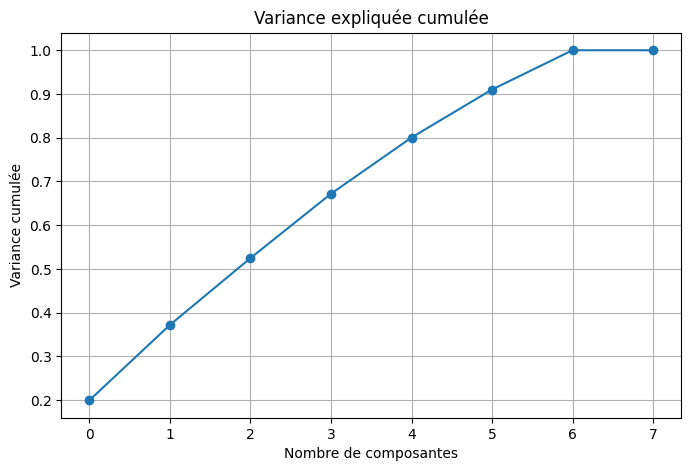

50% variance → 3 composantes
70% variance → 5 composantes
80% variance → 5 composantes


In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# ACP complète
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Variance expliquée
explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

# Affichage simple
plt.figure(figsize=(8,5))
plt.plot(cum_explained, marker='o')
plt.title("Variance expliquée cumulée")
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance cumulée")
plt.grid()
plt.show()

# Nombre de composantes utiles
for t in [0.5, 0.7, 0.8]:
    print(f"{int(t*100)}% variance → {np.argmax(cum_explained >= t)+1} composantes")

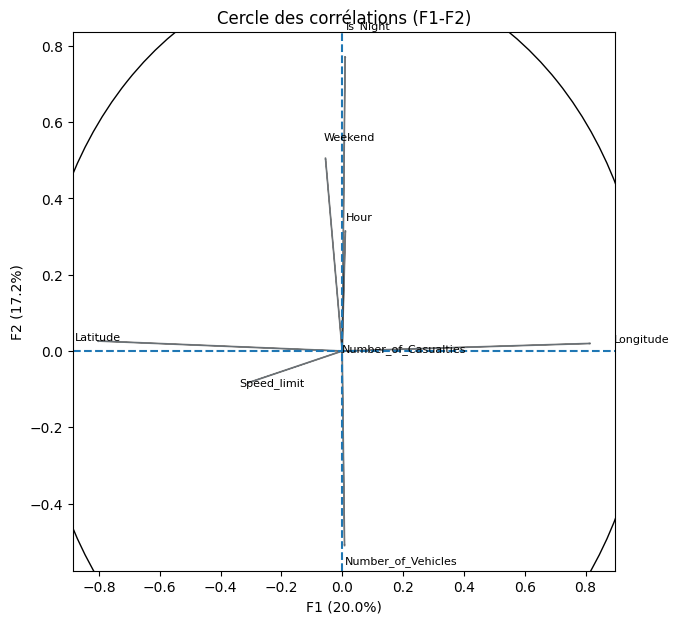

In [6]:
# On garde seulement F1 et F2
components = pca.components_[:2]
eigval = pca.explained_variance_[:2]

# Corrélations
corvar = components.T * np.sqrt(eigval)

plt.figure(figsize=(7,7))

for i in range(len(cols_pca)):
    plt.arrow(0, 0, corvar[i,0], corvar[i,1], alpha=0.5)
    plt.text(corvar[i,0]*1.1, corvar[i,1]*1.1, cols_pca[i], fontsize=8)

# Cercle
circle = plt.Circle((0,0),1, fill=False)
plt.gca().add_artist(circle)

plt.axhline(0, linestyle='--')
plt.axvline(0, linestyle='--')

plt.title("Cercle des corrélations (F1-F2)")
plt.xlabel(f"F1 ({explained[0]*100:.1f}%)")
plt.ylabel(f"F2 ({explained[1]*100:.1f}%)")
plt.show()

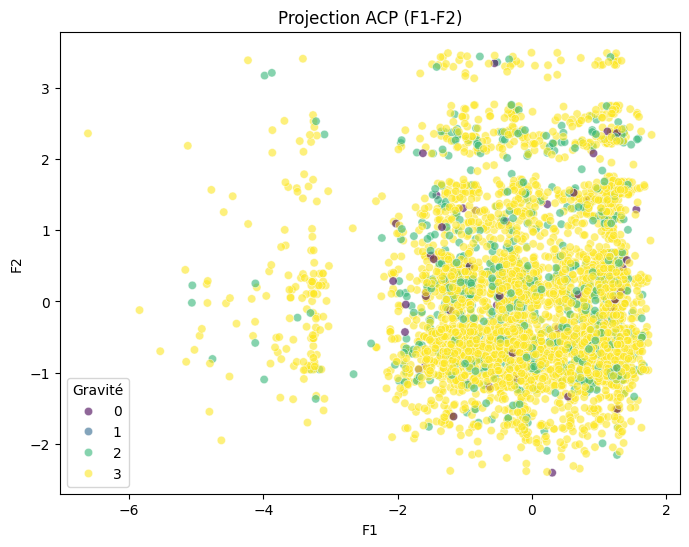

In [7]:
import seaborn as sns

# Échantillon pour lisibilité
sample = np.random.choice(len(X_pca), 5000, replace=False)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[sample, 0],
    y=X_pca[sample, 1],
    hue=df.iloc[sample]['Accident_Severity_encoded'],
    palette='viridis',
    alpha=0.6
)

plt.title("Projection ACP (F1-F2)")
plt.xlabel("F1")
plt.ylabel("F2")
plt.legend(title="Gravité")
plt.show()

In [8]:
df['Number_of_Casualties'] 

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
197639    0.0
197640    0.0
197641    0.0
197642    0.0
197643    0.0
Name: Number_of_Casualties, Length: 197644, dtype: float64

afc

In [10]:
df1 = pd.read_csv('C:/Users/dell/Desktop/projet-datamining/Dataminig-Project/data/processed/data_cleaned1.csv')
# Tableau croisé
D = pd.crosstab(df['Light_Conditions'], df['Accident_Severity_encoded'])

print("Tableau de contingence :")
print(D)

Tableau de contingence :
Accident_Severity_encoded     0   1      2       3
Light_Conditions                                  
0                            13   0    172    1291
1                           605  16   5921   35102
2                            10   0     79     538
3                           328   0   1590    7005
4                          1481  33  17923  125537


In [11]:
import scipy.stats as stats

chi2, p_value, ddl, expected = stats.chi2_contingency(D)

print("Chi2 :", chi2)
print("p-value :", p_value)

if p_value < 0.05:
    print("✅ Relation significative entre surface et gravité")
else:
    print("❌ Pas de relation significative")

Chi2 : 840.8938356774571
p-value : 2.7975726966526333e-172
✅ Relation significative entre surface et gravité


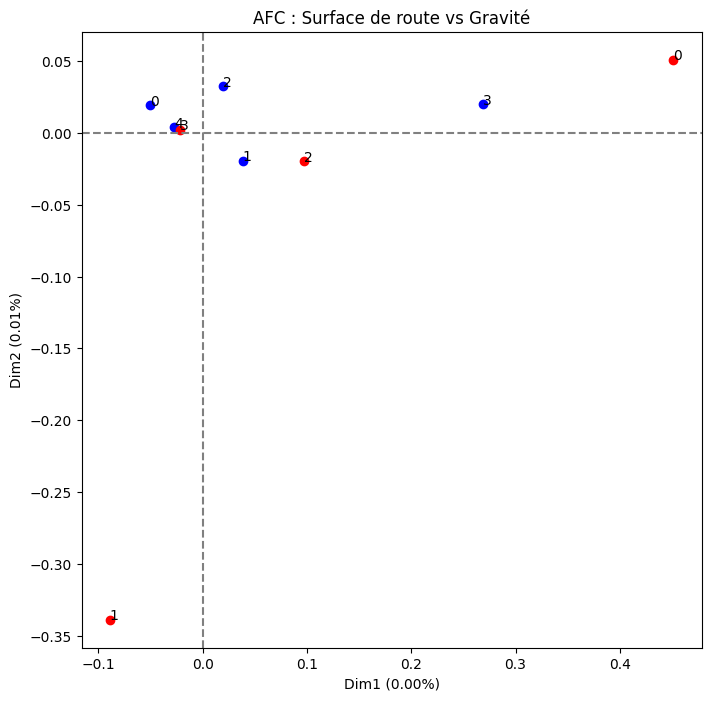

In [12]:
from fanalysis.ca import CA
import matplotlib.pyplot as plt

afc = CA()
afc.fit(D.values)

fig, ax = plt.subplots(figsize=(8, 8))

ax.axhline(0, color='gray', linestyle='--')
ax.axvline(0, color='gray', linestyle='--')

# Lignes (surface route)
for i, txt in enumerate(D.index):
    ax.scatter(afc.row_coord_[i, 0], afc.row_coord_[i, 1], color='blue')
    ax.text(afc.row_coord_[i, 0], afc.row_coord_[i, 1], txt)

# Colonnes (gravité)
for j, txt in enumerate(D.columns):
    ax.scatter(afc.col_coord_[j, 0], afc.col_coord_[j, 1], color='red')
    ax.text(afc.col_coord_[j, 0], afc.col_coord_[j, 1], str(txt))

plt.title("AFC : Surface de route vs Gravité")
plt.xlabel(f"Dim1 ({afc.eig_[0,2]:.2f}%)")
plt.ylabel(f"Dim2 ({afc.eig_[1,2]:.2f}%)")
plt.show()

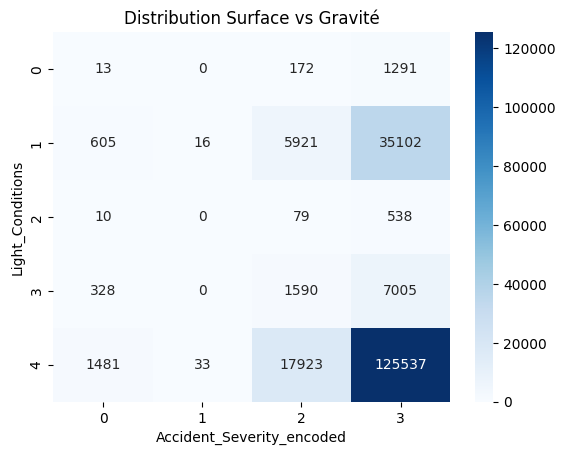

In [13]:
import seaborn as sns

sns.heatmap(D, annot=True, fmt="d", cmap="Blues")
plt.title("Distribution Surface vs Gravité")
plt.show()

In [14]:
print("Variance expliquée :")
print(afc.eig_[:,2])

print("\n👉 Interprétation :")
print("- Les points proches = association forte")
print("- Les points opposés = opposition")
print("- Plus loin du centre = plus important")

Variance expliquée :
[5.35607736e-07 1.25889442e-02 1.00000000e+02]

👉 Interprétation :
- Les points proches = association forte
- Les points opposés = opposition
- Plus loin du centre = plus important


In [15]:
cols_cluster = [
    'Latitude', 'Longitude',
    'Number_of_Casualties',
    'Number_of_Vehicles',
    'Speed_limit',
    'Hour',
    'Is_Night',
    'Weekend',
    'Urban_or_Rural_Area_Urban',
    'Urban_or_Rural_Area_Rural'
]

X = df[cols_cluster].dropna()

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

print("Variance expliquée :", sum(pca.explained_variance_ratio_))

Variance expliquée : 1.0000000000000002


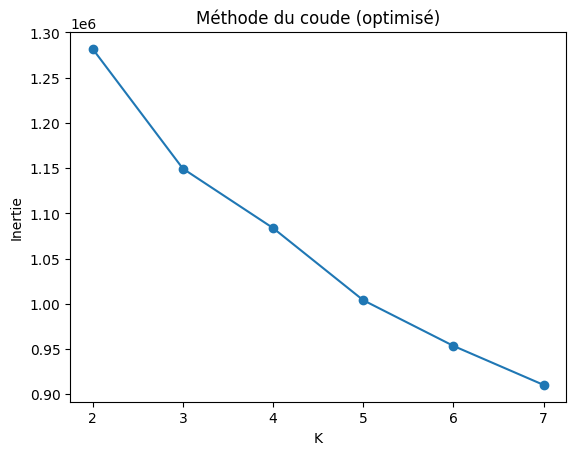

In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 8), inertia, marker='o')
plt.title("Méthode du coude (optimisé)")
plt.xlabel("K")
plt.ylabel("Inertie")
plt.show()

In [19]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster_opt'] = kmeans.fit_predict(X_pca)

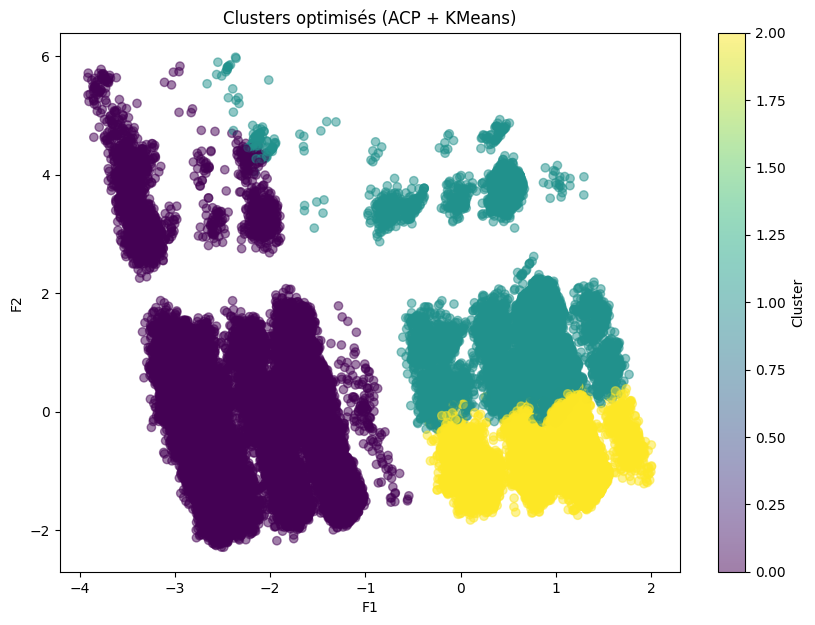

In [20]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[:, 0], 
    X_pca[:, 1], 
    c=df['Cluster_opt'], 
    cmap='viridis', 
    alpha=0.5
)

plt.title("Clusters optimisés (ACP + KMeans)")
plt.xlabel("F1")
plt.ylabel("F2")
plt.colorbar(label="Cluster")
plt.show()

In [22]:
# Variables explicatives (X) et cible (y)
#séparation X / y
X = df.drop(columns=['Accident_Severity_encoded'])
y = df['Accident_Severity_encoded']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (197644, 34)
y shape: (197644,)


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (158115, 34)
Test size: (39529, 34)


In [24]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Modèle entraîné")

Modèle entraîné


In [26]:
y_pred = model.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8550431328897772

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.01      0.02       484
           1       0.00      0.00      0.00         5
           2       0.24      0.01      0.01      5181
           3       0.86      1.00      0.92     33859

    accuracy                           0.86     39529
   macro avg       0.41      0.25      0.24     39529
weighted avg       0.77      0.86      0.79     39529



c:\Users\dell\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dell\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dell\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

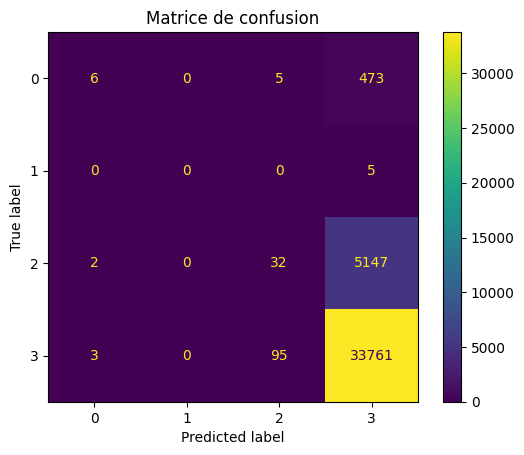

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Matrice de confusion")
plt.show()

In [29]:
import pandas as pd

importances = model.feature_importances_
features = X.columns

df_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(df_importance.head(10))

                               Feature  Importance
3                             Latitude    0.159824
5                            Longitude    0.159804
15  Local_Authority_(District)_encoded    0.101339
12                                Hour    0.095836
11                               Month    0.090539
0                          Day_of_Week    0.061865
16                Police_Force_encoded    0.051578
17                Vehicle_Type_encoded    0.041677
2                      Junction_Detail    0.031777
7                   Number_of_Vehicles    0.031230
